In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/all_players_data.csv")
df.head()

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season,league
0,647,Harry Kane,31,2385,36,29.579986,5,7.403329,119,40,1,0,F M S,Bayern Munich,26,21.244442,34.289579,10.577370,2025,Bundesliga
1,10804,Deniz Undav,29,2261,19,19.057547,6,5.584790,124,38,5,0,F M S,VfB Stuttgart,19,18.299771,30.379802,9.692079,2025,Bundesliga
2,3738,Serhou Guirassy,33,2366,17,19.911182,1,1.929595,84,20,3,0,F S,Borussia Dortmund,16,17.637852,19.162630,4.181204,2025,Bundesliga
3,1236,Patrik Schick,28,2005,16,19.421328,3,3.192039,72,14,2,0,F M S,Bayer Leverkusen,12,15.632445,18.847501,3.710258,2025,Bundesliga
4,9948,Michael Olise,32,2308,15,11.545710,19,17.044203,102,79,8,0,M S,Bayern Munich,15,11.545710,39.008641,16.973004,2025,Bundesliga


## Dataset informations ##

In [3]:
print(df.shape)
print(df.columns)

(13950, 20)
Index(['id', 'player_name', 'games', 'time', 'goals', 'xG', 'assists', 'xA',
       'shots', 'key_passes', 'yellow_cards', 'red_cards', 'position',
       'team_title', 'npg', 'npxG', 'xGChain', 'xGBuildup', 'season',
       'league'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13950 entries, 0 to 13949
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            13950 non-null  int64  
 1   player_name   13950 non-null  object 
 2   games         13950 non-null  int64  
 3   time          13950 non-null  int64  
 4   goals         13950 non-null  int64  
 5   xG            13950 non-null  float64
 6   assists       13950 non-null  int64  
 7   xA            13950 non-null  float64
 8   shots         13950 non-null  int64  
 9   key_passes    13950 non-null  int64  
 10  yellow_cards  13950 non-null  int64  
 11  red_cards     13950 non-null  int64  
 12  position      13950 non-null  object 
 13  team_title    13950 non-null  object 
 14  npg           13950 non-null  int64  
 15  npxG          13950 non-null  float64
 16  xGChain       13950 non-null  float64
 17  xGBuildup     13950 non-null  float64
 18  season        13950 non-nu

In [5]:
df["league"].value_counts()

La_Liga       2966
Serie_A       2944
Ligue_1       2794
EPL           2755
Bundesliga    2491
Name: league, dtype: int64

In [6]:
df["season"].value_counts()

2021    2848
2022    2806
2023    2777
2024    2774
2025    2745
Name: season, dtype: int64

In [7]:
df["id"].nunique()

5689

In [8]:
# Several players have the same name (but diferent id's)
df["player_name"].nunique()

5657

## NA and duplicate ##

In [9]:
df.isna().sum()

id              0
player_name     0
games           0
time            0
goals           0
xG              0
assists         0
xA              0
shots           0
key_passes      0
yellow_cards    0
red_cards       0
position        0
team_title      0
npg             0
npxG            0
xGChain         0
xGBuildup       0
season          0
league          0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
print(df[df["goals"] < 0].empty)
print(df[df["games"] == 0].empty)
print(df.duplicated(subset=["id", "season", "league"], keep=False).sum())

True
True
0


In [12]:
df[df["player_name"]=="Harry Kane"]

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season,league
0,647,Harry Kane,31,2385,36,29.579986,5,7.403329,119,40,1,0,F M S,Bayern Munich,26,21.244442,34.289579,10.577370,2025,Bundesliga
499,647,Harry Kane,31,2400,26,24.838503,9,5.889719,114,36,5,0,F S,Bayern Munich,17,18.018513,30.192511,8.705299,2024,Bundesliga
980,647,Harry Kane,32,2854,36,33.116345,8,6.784329,146,31,2,0,F,Bayern Munich,31,29.327461,38.139976,8.294851,2023,Bundesliga
4156,647,Harry Kane,38,3414,30,23.064440,3,7.547408,133,57,6,0,F,Tottenham,25,18.497427,25.079118,5.095352,2022,EPL
4712,647,Harry Kane,37,3229,17,20.685072,9,9.818289,133,48,5,0,F M S,Tottenham,13,17.640392,31.892184,9.808408,2021,EPL


In [13]:
# Find player_name with multiple Id
players_with_multiple_ids = df.groupby("player_name")["id"].nunique()
names_to_check = players_with_multiple_ids[players_with_multiple_ids > 1].index

print(names_to_check)

Index(['Aaron Ramsey', 'Alessandro Russo', 'Arthur', 'Bernardo', 'Danilo',
       'David López', 'Diego López', 'Emerson', 'Gabriel', 'Idrissa Gueye',
       'Joshua King', 'João Moutinho', 'João Pedro', 'Juan Cruz', 'Kevin',
       'Luis Suárez', 'Mamadou Coulibaly', 'Marcelo', 'Marquinhos',
       'Mohamed Bamba', 'Oier', 'Otávio', 'Ousmane Camara', 'Ruan',
       'Sergio Arribas', 'Stefan Mitrovic', 'Vitinha', 'Wesley',
       'Álvaro Fernández', 'Ángel Alarcón'],
      dtype='object', name='player_name')


In [14]:
print(df[df["player_name"]=="Aaron Ramsey"])

         id   player_name  games  time  goals        xG  assists        xA  \
4053   9913  Aaron Ramsey     14   516      0  0.402008        0  0.391522   
10006   504  Aaron Ramsey     27  1581      1  3.126263        1  2.082380   
13624   504  Aaron Ramsey      3    97      0  0.000000        0  0.150810   

       shots  key_passes  yellow_cards  red_cards position team_title  npg  \
4053       6           1             1          0      M S    Burnley    0   
10006     22          28             3          0      M S       Nice    1   
13624      0           2             0          0      M S   Juventus    0   

           npxG   xGChain  xGBuildup  season   league  
4053   0.402008  1.294434   0.533633    2023      EPL  
10006  3.126263  9.045833   5.283895    2022  Ligue_1  
13624  0.000000  0.904697   0.753887    2021  Serie_A  


## Basic statistics ##

In [15]:
df.describe().round(2)

,id,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,npg,npxG,xGChain,xGBuildup,season
count,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00,13950.00
mean,7512.81,19.55,1257.30,1.73,1.92,1.22,1.36,16.05,11.91,2.51,0.12,1.58,1.77,5.43,3.29,2022.98
std,4016.82,11.48,978.67,3.17,3.13,1.95,1.87,19.81,14.77,2.58,0.36,2.79,2.77,5.59,3.55,1.42
min,3.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2021.00
25%,4459.00,9.00,331.25,0.00,0.08,0.00,0.06,2.00,1.00,0.00,0.00,0.00,0.08,1.05,0.54,2022.00
50%,8050.00,21.00,1130.00,0.00,0.77,0.00,0.64,9.00,7.00,2.00,0.00,0.00,0.74,3.90,2.26,2023.00
75%,10772.00,30.00,2052.75,2.00,2.31,2.00,1.90,22.00,17.00,4.00,0.00,2.00,2.19,7.94,4.83,2024.00
max,14616.00,39.00,3504.00,36.00,37.92,20.00,17.27,161.00,133.00,18.00,3.00,31.00,34.14,48.54,27.68,2025.00


In [16]:
df.groupby("league")["goals"].mean()

league
Bundesliga    1.899237
EPL           1.933575
La_Liga       1.606878
Ligue_1       1.644953
Serie_A       1.622962
Name: goals, dtype: float64

In [17]:
# Average number of players per team, per season
print(df.groupby(["team_title", "season"])["id"].count().mean())
print(df.groupby(["team_title", "season"])["id"].count().min()) # A team with 1 player ?
print(df.groupby(["team_title", "season"])["id"].count().max())

16.6866028708134
1
39


In [18]:
# Group by team and season, count IDs
grouped = df.groupby(["team_title", "season"])["id"].count()

# Keep only those where count == 1
result = grouped[grouped == 1]

print(result)

team_title                        season
AC Milan,Atalanta                 2025      1
AC Milan,Bologna                  2024      1
AC Milan,Fiorentina               2024      1
AC Milan,Napoli                   2024      1
AC Milan,Salernitana              2023      1
                                           ..
Union Berlin,Wolfsburg            2022      1
                                  2023      1
VfB Stuttgart,Wolfsburg           2021      1
Werder Bremen,Wolfsburg           2022      1
West Ham,Wolverhampton Wanderers  2022      1
Name: id, Length: 328, dtype: int64


These team_title refer to players who changed teams mid-season, while remaining in the same league. 

In [19]:
print(df[df["team_title"]=="AC Milan,Atalanta"])

         id  player_name  games  time  goals       xG  assists        xA  \
11233  8771  Yunus Musah     19   533      1  0.68856        0  0.715842   

       shots  key_passes  yellow_cards  red_cards position         team_title  \
11233      6           3             1          0    D M S  AC Milan,Atalanta   

       npg     npxG   xGChain  xGBuildup  season   league  
11233    1  0.68856  4.114252   2.747593    2025  Serie_A  


<AxesSubplot:xlabel='goals', ylabel='Count'>

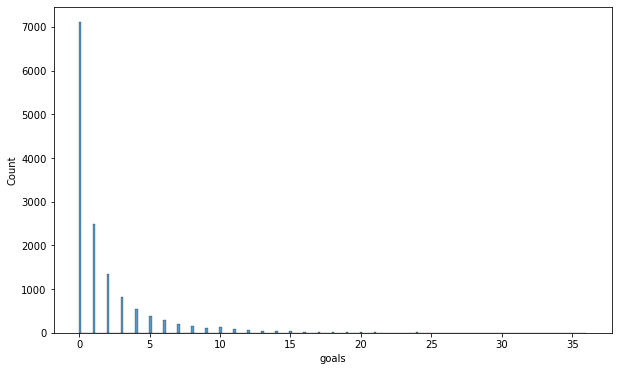

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df["goals"])

In [21]:
df.sort_values(["goals","assists"], ascending=False).head(10)

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season,league
980,647,Harry Kane,32,2854,36,33.116345,8,6.784329,146,31,2,0,F,Bayern Munich,31,29.327461,38.139976,8.294851,2023,Bundesliga
4155,8260,Erling Haaland,35,2803,36,32.761400,8,5.849110,123,29,5,0,F S,Manchester City,29,27.433210,31.963398,3.285816,2022,EPL
0,647,Harry Kane,31,2385,36,29.579986,5,7.403329,119,40,1,0,F M S,Bayern Munich,26,21.244442,34.289579,10.577370,2025,Bundesliga
1980,227,Robert Lewandowski,34,2955,35,37.924069,3,4.701291,160,37,2,0,F,Bayern Munich,30,34.135185,41.541005,7.827050,2021,Bundesliga
5837,3423,Kylian Mbappe-Lottin,34,2938,31,30.135636,3,9.394115,161,51,3,1,F,Real Madrid,24,23.446137,38.313464,11.081680,2024,La_Liga
4156,647,Harry Kane,38,3414,30,23.064440,3,7.547408,133,57,6,0,F,Tottenham,25,18.497427,25.079118,5.095352,2022,EPL
3023,1250,Mohamed Salah,38,3392,29,27.706267,18,15.858334,130,89,1,0,F M,Liverpool,20,20.855748,48.535889,16.206758,2024,EPL
10417,3423,Kylian Mbappe-Lottin,35,3040,29,24.977209,17,12.686746,147,71,10,0,F S,Paris Saint Germain,25,21.936828,40.468102,12.094086,2021,Ligue_1
9832,3423,Kylian Mbappe-Lottin,34,2835,29,27.803833,5,9.169805,150,56,6,0,F S,Paris Saint Germain,26,24.763454,37.204078,9.769715,2022,Ligue_1
981,3738,Serhou Guirassy,28,2228,28,23.512100,3,7.668689,91,53,0,0,F S,VfB Stuttgart,24,20.480993,32.288788,7.664522,2023,Bundesliga
